In [1]:
#!/usr/bin/env python3
import os
import re
import sys
import collections
import argparse
import itertools 
import scipy
import matplotlib
import glob
from tqdm import tqdm

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42



import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from multiprocessing import Pool
from collections import defaultdict
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import hypergeom

import scipy.io as io

In [2]:
length_list = [0, 248956422, 491149951, 689445510, 879660065, 1061198324,
               1232004303, 1391350276, 1536488912, 1674883629, 1808681051,
               1943767673, 2077042982, 2191407310, 2298451028, 2400442217,
               2490780562, 2574038003, 2654411288, 2713028904, 2777473071,
               2824183054, 2875001522, 3031042417]

chr_order = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
             '12', '13', '14', '15', '16', '17', '18', '19', '20',
             '21', '22', 'X', 'Y']

v2_FILE = '/project/GCRB/Hon_lab/shared/former_members/s160875/03.analysis/Mosaic-seq/CROP-DE-analysis_10X-66K_no_downsampling-CPM.hg38/\
combine_10sgRNAs-volcano/generate_annotations/plot_annotation.txt'

annot_df_dup = pd.read_csv(v2_FILE,
        header = None,
        sep='\t',
        names = ['idx', 'gene_names', 'chromosome', 'pos', 'strand', 'color_idx', 'chr_idx'])

In [3]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [4]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

In [5]:
TF_region_df.head(3)

,TF
chr11:5301689-5301949,OR51B4
chr19:51887666-51887940,ZNF577
chrX:72276872-72277245,RPS4X


### Slice repetitive elements and zinc finger protein

In [6]:
RE_annotation_df = pd.read_csv('/project/GCRB/Hon_lab/s159317/IGVF/scTE_mapping/CM.TF-Perturb-Seq/temp/rmsk.txt', sep='\t', 
                               names=['1', '2', '3', '4', '5', 'chr', 'start', 'end', 'pos', 'strand', 'name', 'cate', 'names', '6', '7', '8', '9'])

In [7]:
RE_annotation_df.head()

,1,2,3,4,5,chr,start,end,pos,strand,name,cate,names,6,7,8,9
0,585,463,13,6,17,chr1,10000,10468,-248945954,+,(TAACCC)n,Simple_repeat,Simple_repeat,1,471,0,1
1,585,3612,114,215,13,chr1,10468,11447,-248944975,-,TAR1,Satellite,telo,-399,1712,483,2
2,585,484,251,132,0,chr1,11504,11675,-248944747,-,L1MC5a,LINE,L1,-2382,395,199,3
3,585,239,294,19,10,chr1,11677,11780,-248944642,-,MER5B,DNA,hAT-Charlie,-74,104,1,4
4,585,318,230,37,0,chr1,15264,15355,-248941067,-,MIR3,SINE,MIR,-119,143,49,5


In [8]:
RE_family_dict = dict(RE_annotation_df[["name","cate"]].values)

### Load DE table

In [9]:
GLBOAL_HITS = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/unfiltered_global_df.csv'
FILE_DIR = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/'

In [10]:
df_column_list = [
    'idx', 'gene_names', 'chromosome', 'pos', 'strand', 
    'color_idx', 'chr_idx', 
    'region', 'num_cell', 'bin',
    'log(pval)-hypergeom', 'fc', 'Significance_score', 'fc_by_rand_dist_cpm', 'pval-empirical', 'cpm_perturb', 'cpm_bg']

In [11]:
global_df = pd.read_csv(GLBOAL_HITS)[df_column_list]

In [12]:
global_df['TF_annotation'] = [annot_dict[i] for i in global_df['region']]

In [13]:
global_df_TE = global_df.loc[global_df["gene_names"].isin(RE_annotation_df["name"])]

### Load expression data

In [14]:
CUTOFF_EXP = 0.05
CUTOFF_FC = 0.2
CUTOFF_SIG = -14

In [15]:
#Load expressed genes 
gene_seq = np.load(FILE_DIR + 'Trans_genome_seq.npy', allow_pickle=True)
express_level = np.load(FILE_DIR + 'Perc_cell_expr.npy')
express_idx = np.where(express_level > CUTOFF_EXP)[0]

In [16]:
exp_percent_df = pd.DataFrame([gene_seq,express_level]).T
exp_percent_df.columns = ["Name","express_level"]

In [17]:
np.percentile(exp_percent_df.loc[
    exp_percent_df["Name"].isin(RE_annotation_df["name"])]["express_level"],2.5)

0.044656873890260296

### Process zinc finger table and prepare table for heatmap

In [18]:
express_df = global_df[global_df['gene_names'].isin(gene_seq[express_idx]) &
                       ((global_df['fc_by_rand_dist_cpm'] > (1+CUTOFF_FC)) | (global_df['fc_by_rand_dist_cpm'] < (1-CUTOFF_FC))) &
                       (global_df['Significance_score'] < CUTOFF_SIG) &
                       (global_df['pval-empirical'] < 0.001) &
                       (global_df['log(pval)-hypergeom'] < -3)].copy()

In [19]:
zinc_fing_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/zinc_finger_gene_list.txt', sep='\t')

In [20]:
subset_express_df = express_df[(express_df['gene_names'].isin(RE_annotation_df['name'])) &
                               (express_df['TF_annotation'].isin(list(zinc_fing_df['Approved symbol'])))
                              ]
express_df_TE = express_df[(express_df['gene_names'].isin(RE_annotation_df['name']))
                       ]

In [21]:
subset_express_df.shape

(59, 18)

In [22]:
subset_express_df_sub = subset_express_df.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
subset_express_df_sub["Significance_score_correct"] = subset_express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

subset_express_df_sub = \
    subset_express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [23]:
express_df_sub = express_df_TE.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
express_df_sub["Significance_score_correct"] = express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

express_df_sub = \
    express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [24]:
subset_express_df.shape

(59, 18)

In [25]:
subset_express_df_pivot = subset_express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
subset_express_df_pivot = subset_express_df_pivot.fillna(0)

express_df_pivot = express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
express_df_pivot = express_df_pivot.fillna(0)

###  generate heatmap

<Axes: xlabel='TF_annotation', ylabel='gene_names'>

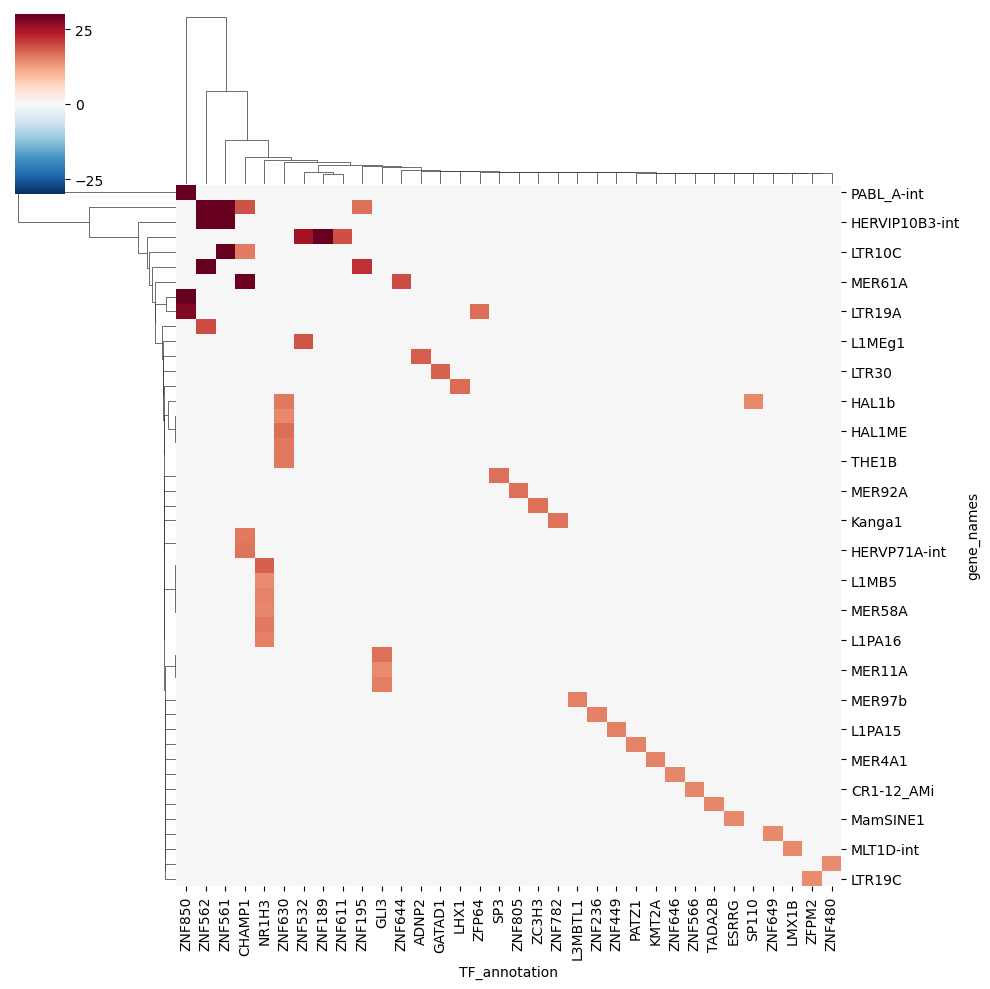

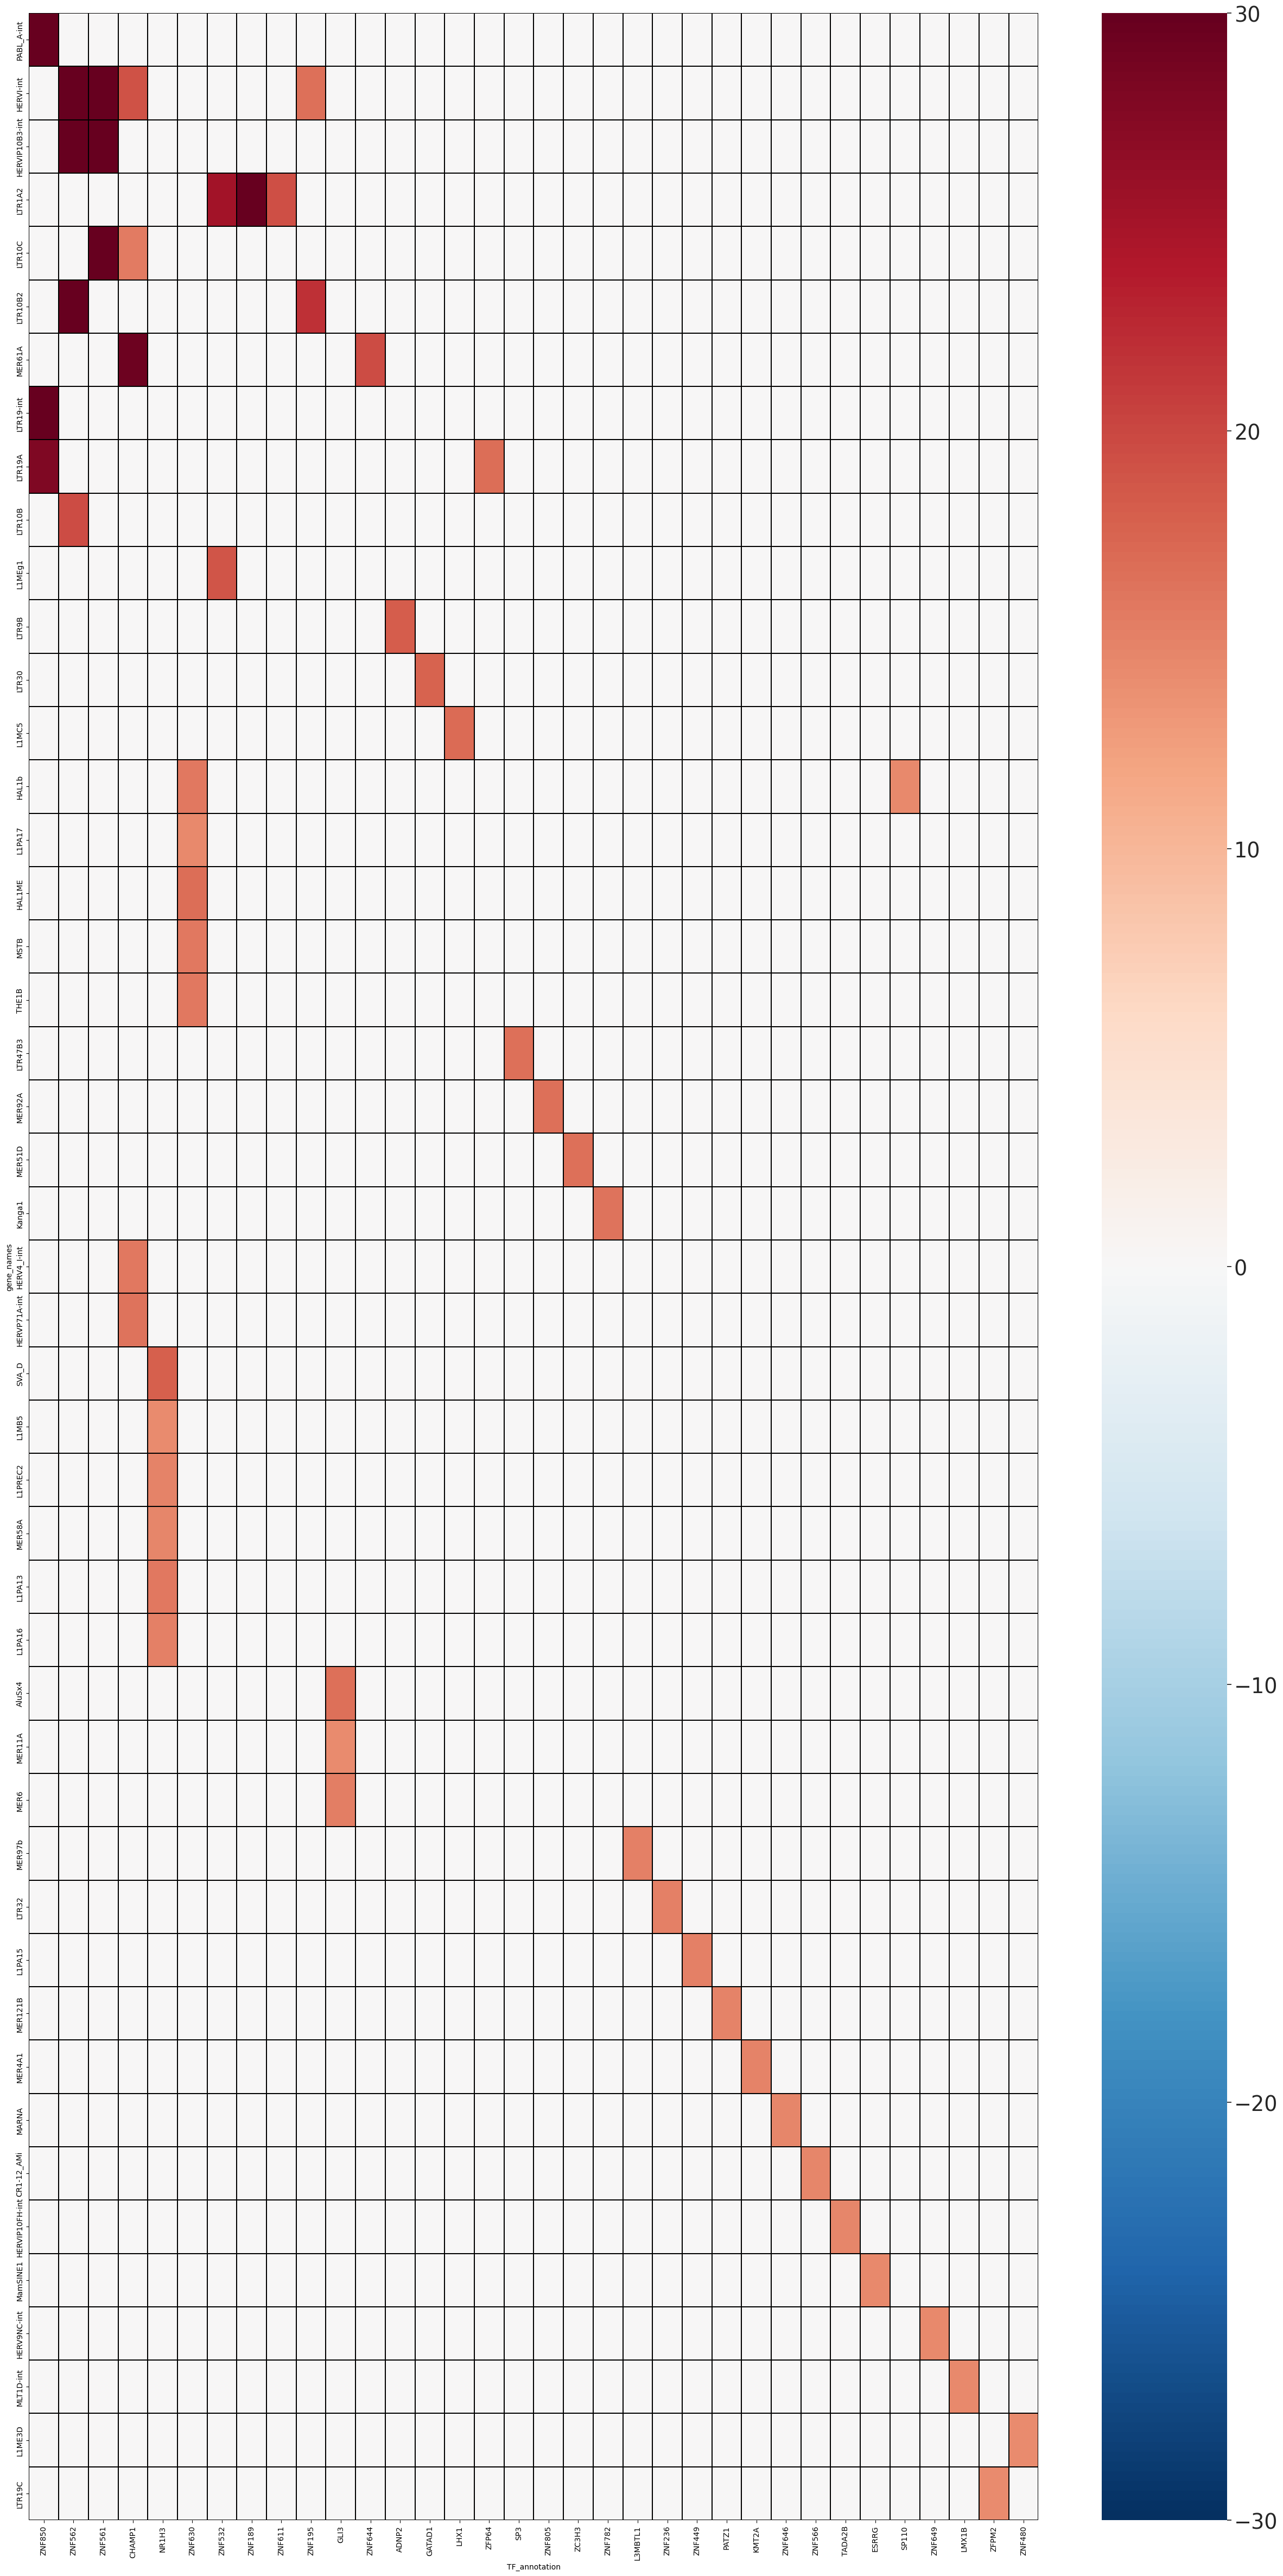

In [26]:
g = sns.clustermap(subset_express_df_pivot,vmax=30, vmin=-30,cmap='RdBu_r')
fig, ax = plt.subplots(figsize=(30, 60))
sns.set(font_scale=2.5)
sns.heatmap(subset_express_df_pivot.iloc[g.dendrogram_row.reordered_ind, g.dendrogram_col.reordered_ind].astype(float), 
            cmap='RdBu_r', ax=ax, vmax=30, vmin=-30, rasterized=True,linewidths=0.01,linecolor='black')
#plt.show() 

###  Include all the TFs

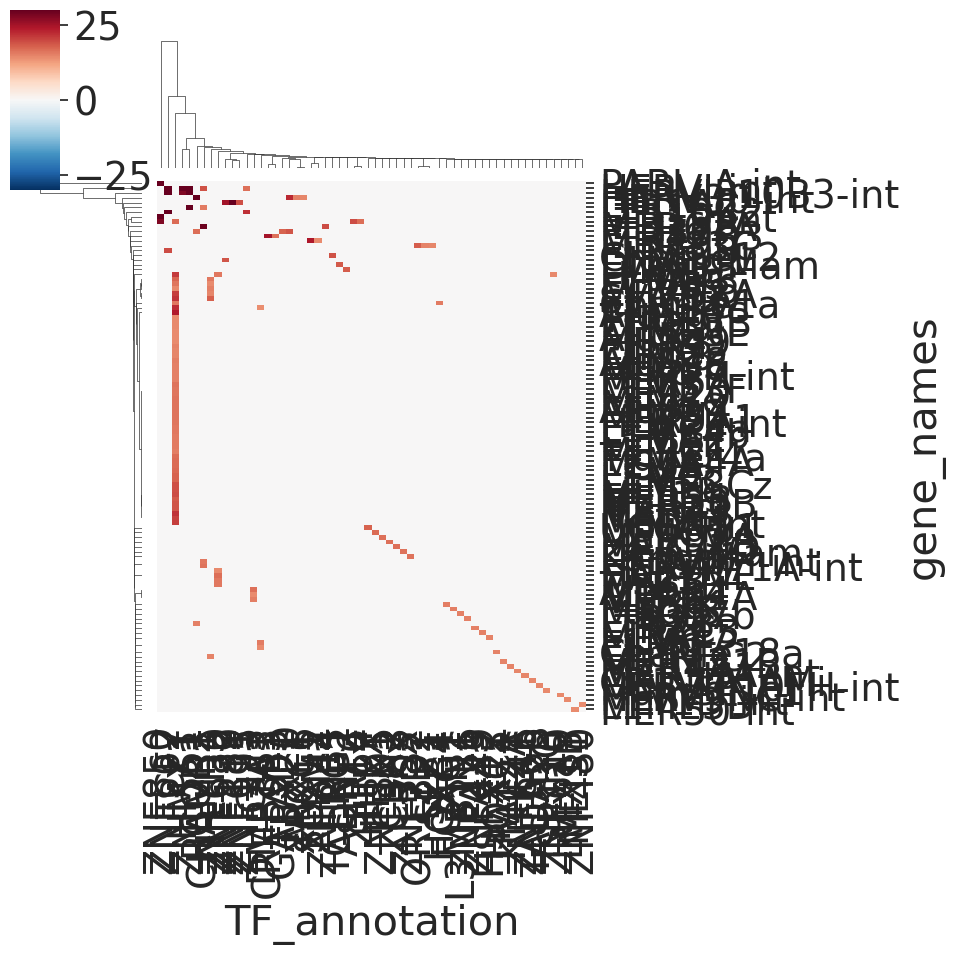

In [27]:
g2 = sns.clustermap(express_df_pivot, cmap='RdBu_r', vmin=-30, vmax=30, yticklabels=True, xticklabels=True)

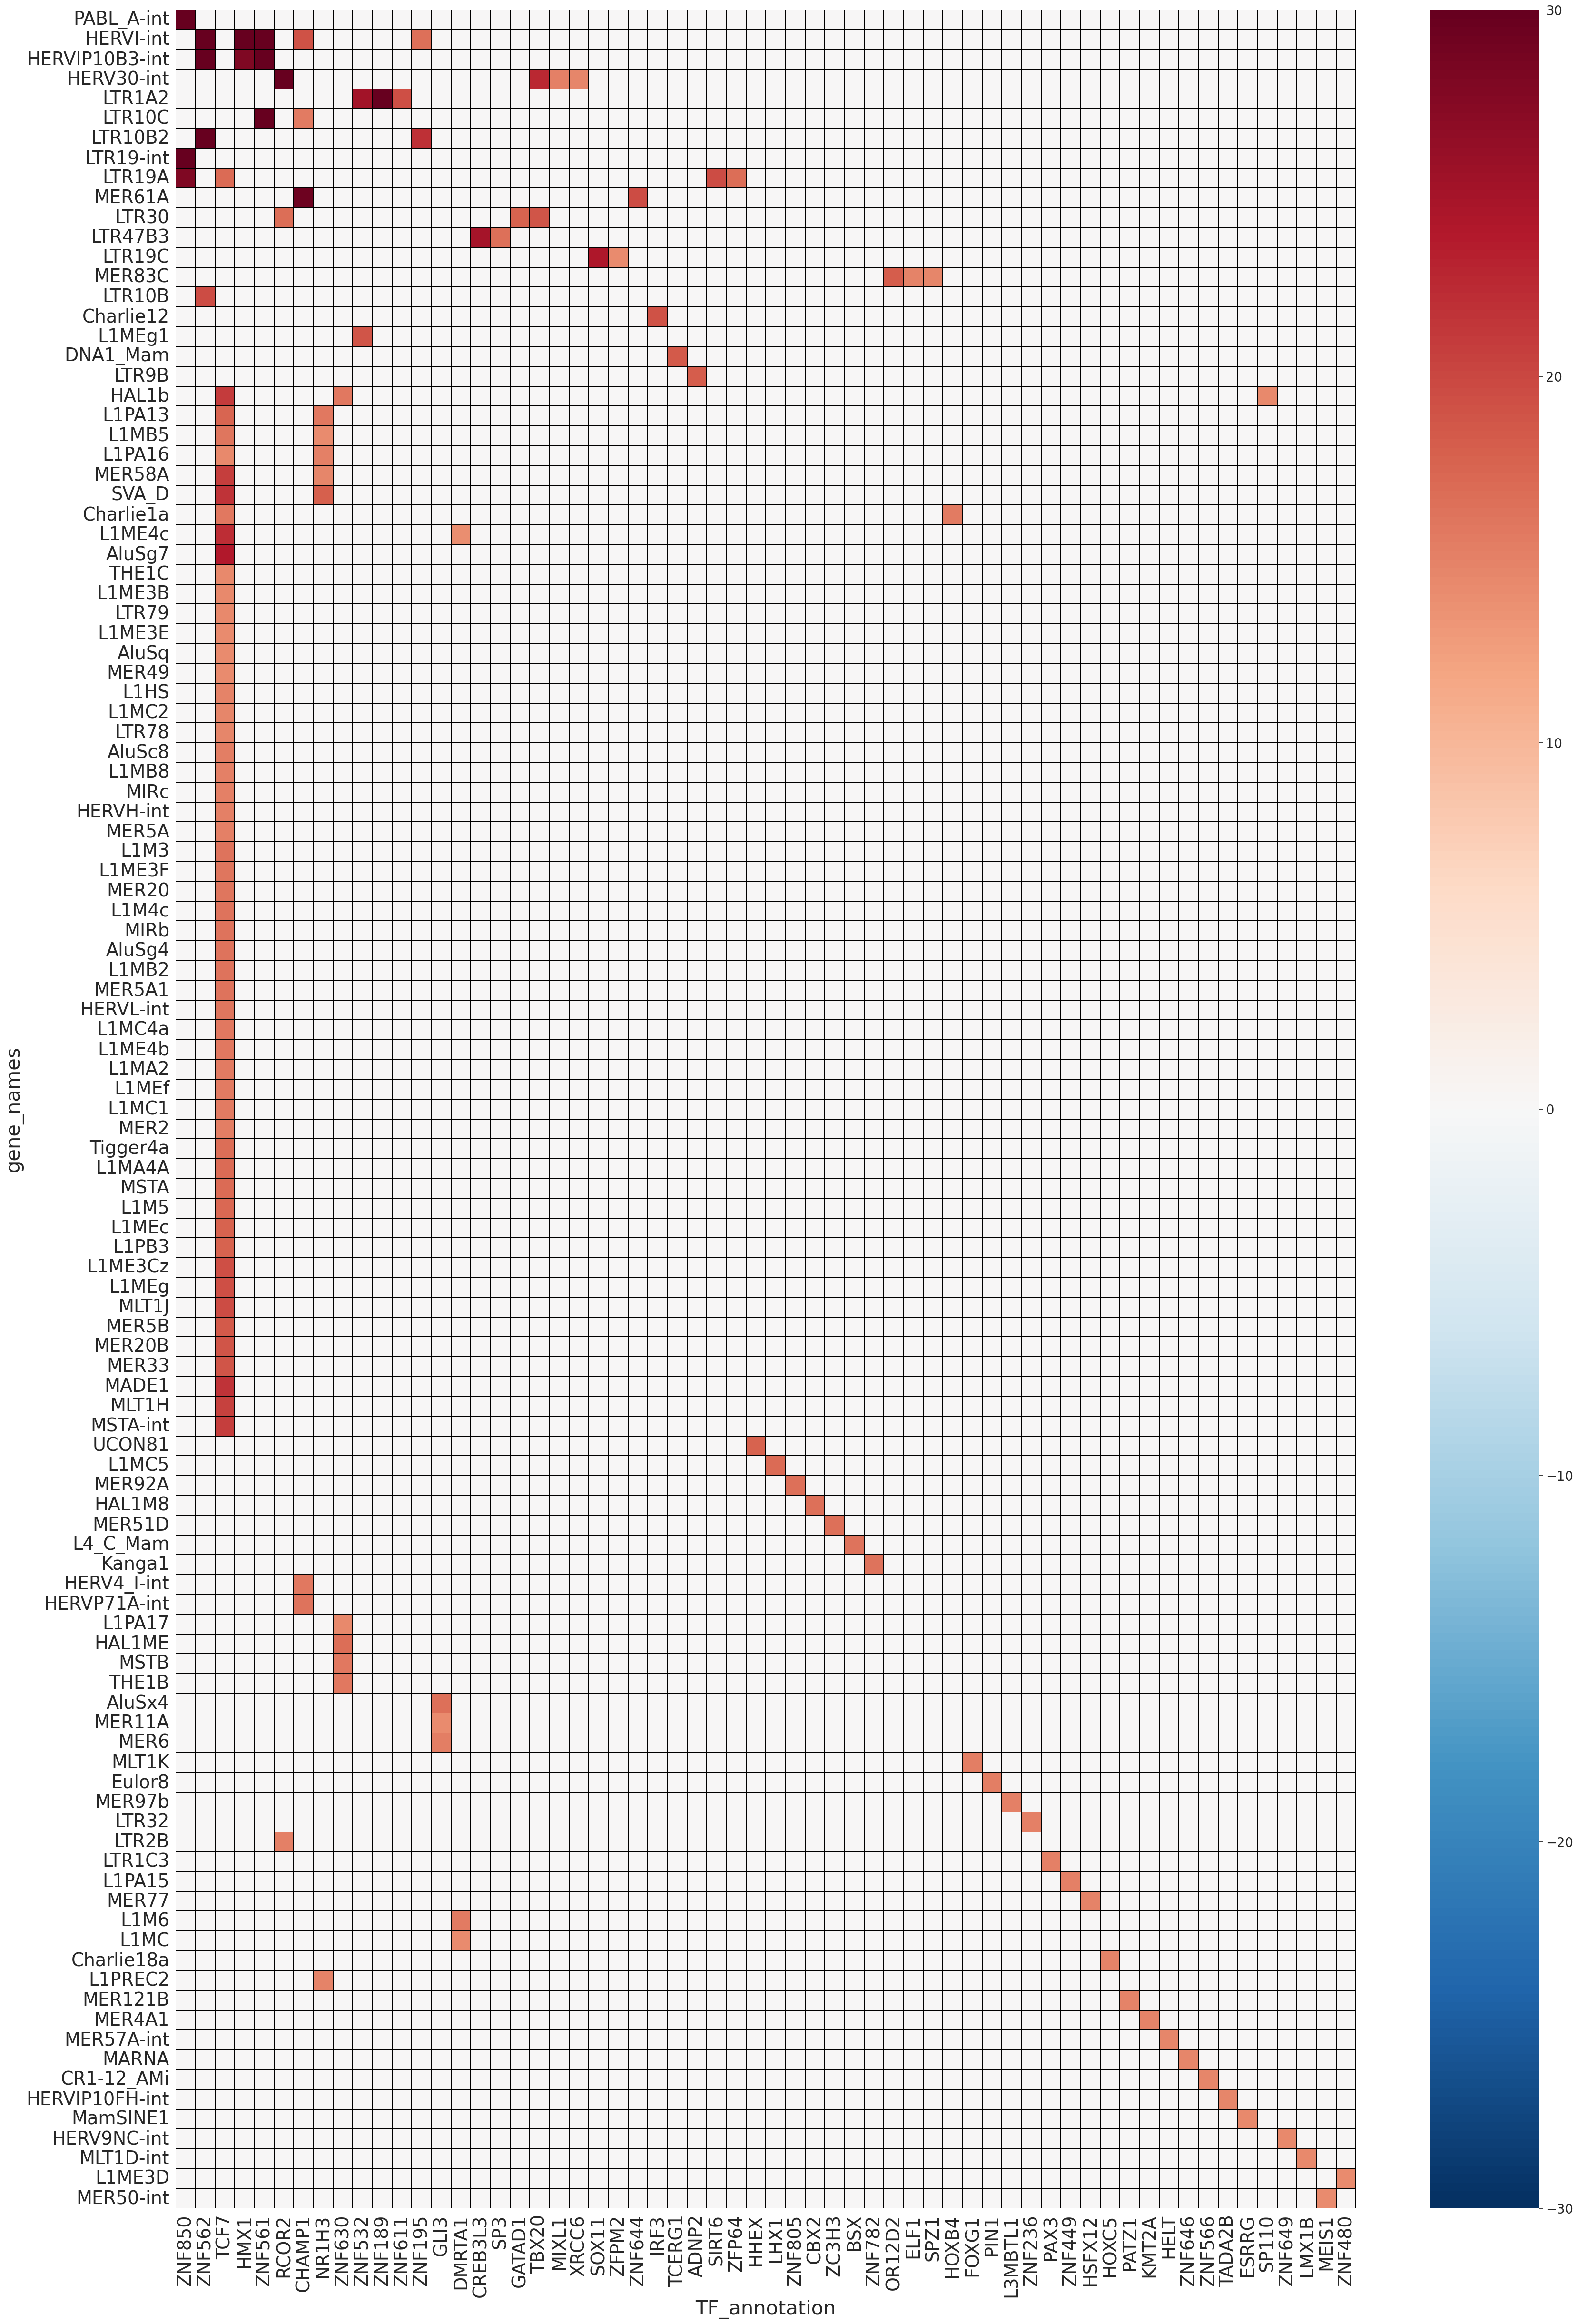

In [28]:
fig, ax = plt.subplots(figsize=(40, 60))
sns.set(font_scale=1.8)
sns.heatmap(express_df_pivot.iloc[g2.dendrogram_row.reordered_ind, g2.dendrogram_col.reordered_ind].astype(float), 
            cmap='RdBu_r', ax=ax, vmax=30, vmin=-30, rasterized=True, linewidths=0.01, linecolor='black')
plt.savefig("./figure/TF_full_heatmap.pdf")

### Focus on specific TFs

In [29]:
name,count = np.unique(express_df_TE["TF_annotation"],return_counts=True)
dict(zip(name,count))

{'ADNP2': 1,
 'BSX': 1,
 'CBX2': 1,
 'CHAMP1': 5,
 'CREB3L3': 1,
 'DMRTA1': 3,
 'ELF1': 1,
 'ESRRG': 1,
 'FOXG1': 1,
 'GATAD1': 1,
 'GLI3': 3,
 'HELT': 1,
 'HHEX': 1,
 'HMX1': 2,
 'HOXB4': 1,
 'HOXC5': 1,
 'HSFX12': 1,
 'IRF3': 1,
 'KMT2A': 1,
 'L3MBTL1': 1,
 'LHX1': 1,
 'LMX1B': 1,
 'MEIS1': 1,
 'MIXL1': 1,
 'NR1H3': 6,
 'OR12D2': 1,
 'PATZ1': 1,
 'PAX3': 1,
 'PIN1': 1,
 'RCOR2': 3,
 'SIRT6': 1,
 'SOX11': 1,
 'SP110': 1,
 'SP3': 1,
 'SPZ1': 1,
 'TADA2B': 1,
 'TBX20': 2,
 'TCERG1': 1,
 'TCF7': 54,
 'XRCC6': 1,
 'ZC3H3': 1,
 'ZFP64': 1,
 'ZFPM2': 1,
 'ZNF189': 1,
 'ZNF195': 2,
 'ZNF236': 1,
 'ZNF449': 1,
 'ZNF480': 1,
 'ZNF532': 3,
 'ZNF561': 3,
 'ZNF562': 4,
 'ZNF566': 1,
 'ZNF611': 1,
 'ZNF630': 5,
 'ZNF644': 1,
 'ZNF646': 1,
 'ZNF649': 1,
 'ZNF782': 1,
 'ZNF805': 1,
 'ZNF850': 3}

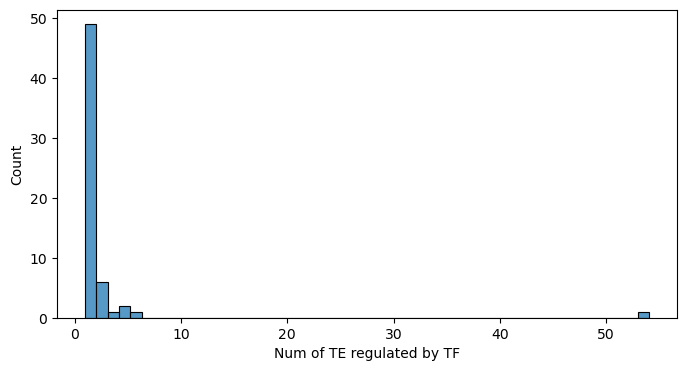

In [30]:
plt.rcdefaults()
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig,ax=plt.subplots(figsize=(8,4))
ax.set_xlabel("Num of TE regulated by TF")
sns.histplot(count,bins=50)

plt.savefig("./figure/num_of_TE_regulated.pdf")

In [31]:
name,count = np.unique(express_df_TE["gene_names"],return_counts=True)
dict(zip(name,count))

{'AluSc8': 1,
 'AluSg4': 1,
 'AluSg7': 1,
 'AluSq': 1,
 'AluSx4': 1,
 'CR1-12_AMi': 1,
 'Charlie12': 1,
 'Charlie18a': 1,
 'Charlie1a': 2,
 'DNA1_Mam': 1,
 'Eulor8': 1,
 'HAL1M8': 1,
 'HAL1ME': 1,
 'HAL1b': 3,
 'HERV30-int': 4,
 'HERV4_I-int': 1,
 'HERV9NC-int': 1,
 'HERVH-int': 1,
 'HERVI-int': 5,
 'HERVIP10B3-int': 3,
 'HERVIP10FH-int': 1,
 'HERVL-int': 1,
 'HERVP71A-int': 1,
 'Kanga1': 1,
 'L1HS': 1,
 'L1M3': 1,
 'L1M4c': 1,
 'L1M5': 1,
 'L1M6': 1,
 'L1MA2': 1,
 'L1MA4A': 1,
 'L1MB2': 1,
 'L1MB5': 2,
 'L1MB8': 1,
 'L1MC': 1,
 'L1MC1': 1,
 'L1MC2': 1,
 'L1MC4a': 1,
 'L1MC5': 1,
 'L1ME3B': 1,
 'L1ME3Cz': 1,
 'L1ME3D': 1,
 'L1ME3E': 1,
 'L1ME3F': 1,
 'L1ME4b': 1,
 'L1ME4c': 2,
 'L1MEc': 1,
 'L1MEf': 1,
 'L1MEg': 1,
 'L1MEg1': 1,
 'L1PA13': 2,
 'L1PA15': 1,
 'L1PA16': 2,
 'L1PA17': 1,
 'L1PB3': 1,
 'L1PREC2': 1,
 'L4_C_Mam': 1,
 'LTR10B': 1,
 'LTR10B2': 2,
 'LTR10C': 2,
 'LTR19-int': 1,
 'LTR19A': 4,
 'LTR19C': 2,
 'LTR1A2': 4,
 'LTR1C3': 1,
 'LTR2B': 1,
 'LTR30': 3,
 'LTR32': 1,
 'LTR4

In [32]:
max(count)

5

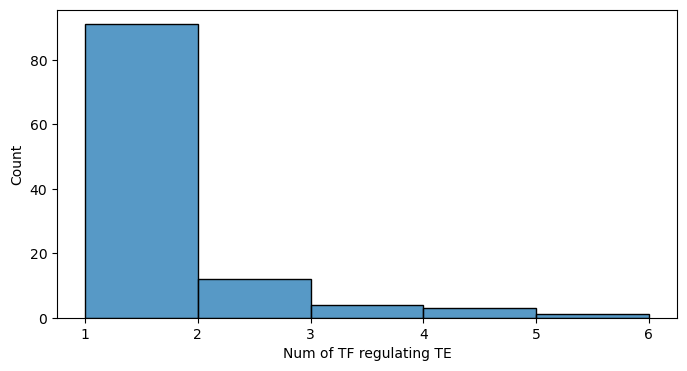

In [33]:
plt.rcdefaults()
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

fig,ax=plt.subplots(figsize=(8,4))
ax.set_xlabel("Num of TF regulating TE")
sns.histplot(count,bins=[1,2,3,4,5,6])

plt.savefig("./figure/num_of_TF_regulating.pdf")

In [34]:
RE_family_dict

{'(TAACCC)n': 'Simple_repeat',
 'TAR1': 'Satellite',
 'L1MC5a': 'LINE',
 'MER5B': 'DNA',
 'MIR3': 'SINE',
 '(TGCTCC)n': 'Simple_repeat',
 '(TGG)n': 'Simple_repeat',
 'L2a': 'LINE',
 'L3': 'LINE',
 'Plat_L3': 'LINE',
 'MLT1K': 'LTR',
 'MIR': 'SINE',
 'L2b': 'LINE',
 'MIR1_Amn': 'SINE',
 'L2c': 'LINE',
 'AluSp': 'SINE',
 'MER33': 'DNA',
 'MIRb': 'SINE',
 '(ACGCCC)n': 'Simple_repeat',
 'L1MB3': 'LINE',
 'MER53': 'DNA',
 'MLT1A': 'LTR',
 '(TC)n': 'Simple_repeat',
 'MIRc': 'SINE',
 'AluJo': 'SINE',
 'L1MB5': 'LINE',
 'Alu': 'SINE',
 'L1PA6': 'LINE',
 'L1P1': 'LINE',
 'MLT1J2': 'LTR',
 'AluJr': 'SINE',
 'Charlie5': 'DNA',
 'MLT1E1A-int': 'LTR',
 'MLT1E1A': 'LTR',
 'AluSx': 'SINE',
 'AluSz6': 'SINE',
 'LTR16C': 'LTR',
 'ERV3-16A3_I-int': 'LTR',
 'MamRep1527': 'LTR',
 'L1MA8': 'LINE',
 '(AAAT)n': 'Simple_repeat',
 'L1M5': 'LINE',
 'L1MA9': 'LINE',
 'LTR12F': 'LTR',
 'MER45A': 'DNA',
 'MER58A': 'DNA',
 'L1PA14': 'LINE',
 '(AACAA)n': 'Simple_repeat',
 '(GT)n': 'Simple_repeat',
 '(TTCCT)n': 'Simp

In [35]:
TCF7_regulating_RE = express_df_TE[express_df_TE["TF_annotation"]=="TCF7"]["gene_names"].values

In [36]:
TCF7_regulating_RE

array(['AluSc8', 'AluSg4', 'AluSg7', 'AluSq', 'Charlie1a', 'HAL1b',
       'HERVH-int', 'HERVL-int', 'L1HS', 'L1M3', 'L1M4c', 'L1M5', 'L1MA2',
       'L1MA4A', 'L1MB2', 'L1MB5', 'L1MB8', 'L1MC1', 'L1MC2', 'L1MC4a',
       'L1ME3B', 'L1ME3Cz', 'L1ME3E', 'L1ME3F', 'L1ME4b', 'L1ME4c',
       'L1MEc', 'L1MEf', 'L1MEg', 'L1PA13', 'L1PA16', 'L1PB3', 'LTR19A',
       'LTR78', 'LTR79', 'MADE1', 'MER2', 'MER20', 'MER20B', 'MER33',
       'MER49', 'MER58A', 'MER5A', 'MER5A1', 'MER5B', 'MIRb', 'MIRc',
       'MLT1H', 'MLT1J', 'MSTA', 'MSTA-int', 'SVA_D', 'THE1C', 'Tigger4a'],
      dtype=object)

In [37]:
name,counts = np.unique([RE_family_dict[x] for x in TCF7_regulating_RE],return_counts=True)
TCF7_regulating_family = pd.DataFrame([name,counts]).T
TCF7_regulating_family.columns=["family","count"]
TCF7_regulating_family = TCF7_regulating_family[TCF7_regulating_family["family"]!="Retroposon"]

name,counts = np.unique([RE_family_dict[x] for x in expressing_TE_name],return_counts=True)
expressing_family = pd.DataFrame([name,counts]).T
expressing_family.columns=["family","count"]
expressing_family = expressing_family[expressing_family["family"]!="Retroposon"]

NameError: name 'expressing_TE_name' is not defined

In [ ]:
TCF7_regulating_family

In [ ]:
TCF7_regulating_family["percent"] = TCF7_regulating_family["count"]/np.sum(TCF7_regulating_family["count"])*100
expressing_family["percent"] = expressing_family["count"]/np.sum(expressing_family["count"])*100

In [ ]:
TCF7_regulating_family_melt = \
    TCF7_regulating_family.melt(ignore_index=False,id_vars="family")
TCF7_regulating_family_melt["source"] = "TCF7"

expressing_family_melt = \
    expressing_family.melt(ignore_index=False,id_vars="family")
expressing_family_melt["source"] = "All"

df_plot = pd.concat([TCF7_regulating_family_melt,expressing_family_melt])

In [ ]:
df_plot_count = df_plot[df_plot["variable"]=="count"]
df_plot_percent = df_plot[df_plot["variable"]=="percent"]

Retroposon is denoted as SVA

In [ ]:
fig,ax=plt.subplots(figsize=(8,4))
sns.barplot(TCF7_regulating_family,x="family",y="count")
plt.savefig("./figure/TCF7_regulating_RE.pdf")

In [ ]:
fig,ax=plt.subplots(figsize=(8,4))
sns.barplot(expressing_family,x="family",y="count")
plt.savefig("./figure/epxressing_RE.pdf")

In [ ]:
fig,ax=plt.subplots(figsize=(8,4))
ax.set_ylim(0,60)
sns.barplot(df_plot_percent,x="family",y="value",hue="source")
plt.savefig("./figure/family_enrichment.pdf")

In [ ]:
total_num = np.sum(df_plot_count[(df_plot_count["source"]=="All")]["value"])
total_regulated_num = np.sum(df_plot_count[(df_plot_count["source"]=="TCF7")]["value"])
prb_list = []

for family_name in np.unique(df_plot_count["family"]):
    x = df_plot_count[(df_plot_count["family"]==family_name) &
                      (df_plot_count["source"]=="TCF7")
                     ]["value"].values[0]
    M = df_plot_count[(df_plot_count["family"]==family_name) &
                      (df_plot_count["source"]=="All")
                     ]["value"].values[0]
    prb = round(1-hypergeom.cdf(x,total_num,total_regulated_num,M),8)
    prb_list.append(min([prb,1-prb]))
    print(family_name,prb,1-prb)

In [ ]:
rank_arr = np.argsort(np.argsort(prb_list))+1
prb_list_adj = []

for i,pval in enumerate(prb_list):
    print(max(rank_arr)/rank_arr[i])
    adj_prb = pval*max(rank_arr)/rank_arr[i]
    prb_list_adj.append(adj_prb)
print(prb_list_adj)